In [2]:
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
import cv2

print(tf.config.list_physical_devices())  
from tensorflow import keras
from tensorflow.python.client import device_lib

print(tf.__version__)
print(keras.__version__)

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]
2.21.0
3.15.0


In [3]:
(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

In [4]:
class_name = [
    'airplane',
    'automobile',
    'bird',
    'cat',
    'deer',
    'dog',
    'frog',
    'horse',
    'ship',
    'truck'
]

In [5]:
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

(50000, 32, 32, 3)
(50000, 1)
(10000, 32, 32, 3)
(10000, 1)


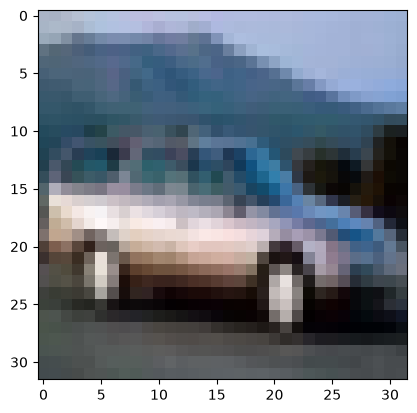

In [6]:
# plt.figure(figsize=(10,10))
plt.imshow(x_train[4], cmap="gray_r")

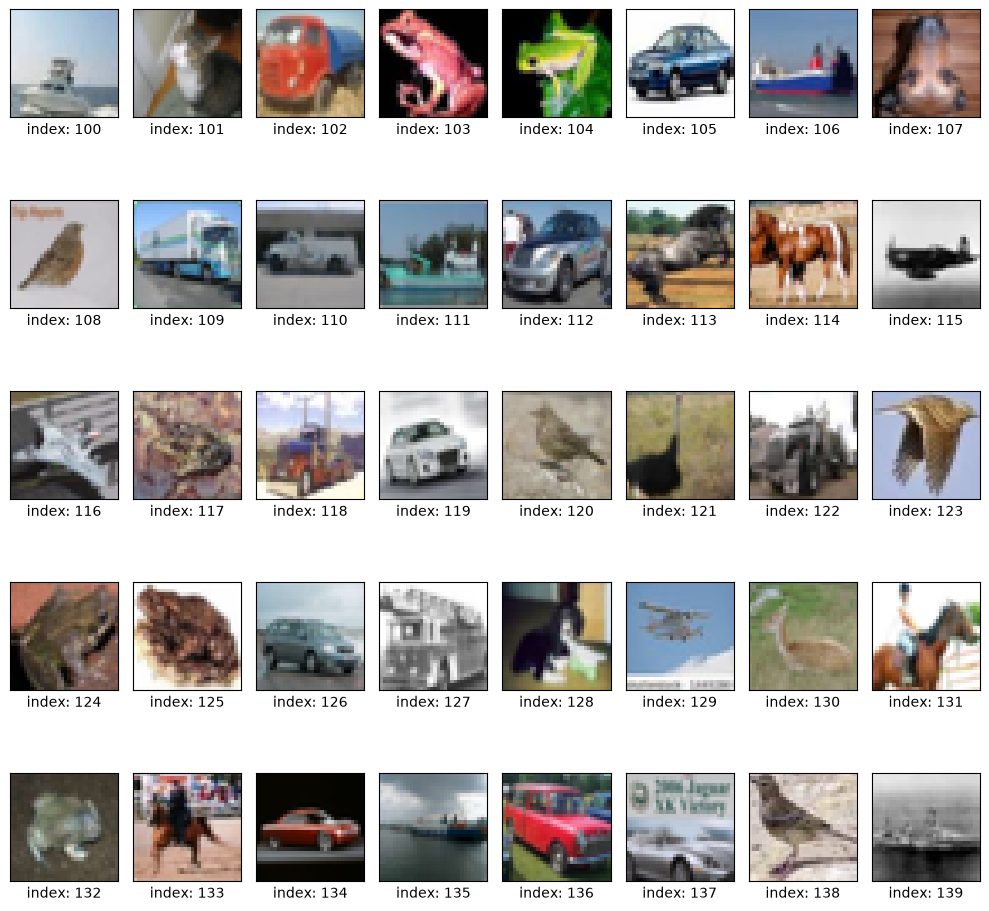

In [7]:
plt.figure(figsize=(10,10))
# print(len(train_images))
for i in range(40):
    plt.subplot(5, 8, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(x_train[i+100], cmap="Pastel1")
    plt.xlabel(f"index: {i+100}")
    plt.grid(True)
plt.tight_layout()
plt.show()

In [8]:
print(type(y_train[100]))
print(y_train[100])
print(y_train[100].shape)
print(class_name[y_train[100][0]])

<class 'numpy.ndarray'>
[8]
(1,)
ship


In [9]:
print(type(y_train[101]))
print(y_train[101])
print(y_train[101].shape)
print(class_name[y_train[101][0]])

<class 'numpy.ndarray'>
[3]
(1,)
cat


[0 1 2 3 4 5 6 7 8 9]
[103  89 100 103  90  86 112 102 106 109]


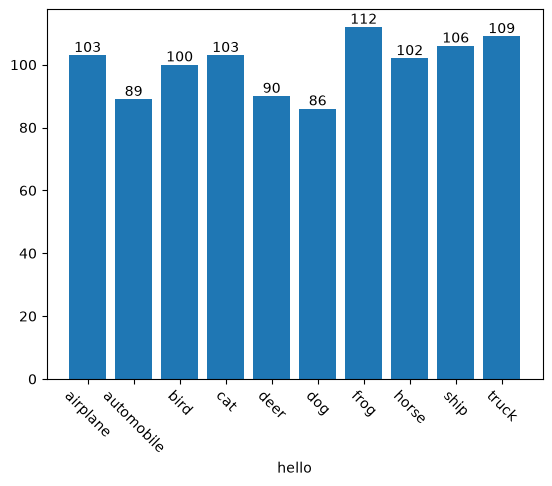

In [10]:
classes, counts = np.unique(y_test[:1000], return_counts = True)
print(classes)
print(counts)
bars = plt.bar(class_name, counts)
plt.bar_label(bars)
# plt.bar(classes, counts)
plt.xlabel("hello")
plt.xticks(rotation = -45)
plt.show()

In [11]:
model1 = keras.Sequential()
model1.add(keras.Input(shape=(16,16)))
model1.add(keras.layers.Dense(8))
len(model1.weights)  # 2 (weights + biases already exist)

2

In [12]:
model1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16, 8)          │           136 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 136 (544.00 B)

 Trainable params: 136 (544.00 B)

 Non-trainable params: 0 (0.00 B)

In [25]:
model_test = keras.Sequential()
model_test.add(keras.layers.Flatten(input_shape=(32,32, 3)))
model_test.add(keras.layers.Dense(10, activation=tf.nn.softmax))


In [26]:
model_test.compile(
    optimizer=keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

In [27]:
model_test.summary()

Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_5 (Flatten)             │ (None, 3072)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │        30,730 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 30,730 (120.04 KB)

 Trainable params: 30,730 (120.04 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
x_train = x_train / 255.0
x_test = x_test / 255.0

In [29]:
print(x_train.max(), x_test.max())

1.0 1.0


In [30]:
model_test.fit(x_train, y_train, epochs = 5)

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.3185 - loss: 1.9614
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.3525 - loss: 1.8795
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.3637 - loss: 1.8586
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.3694 - loss: 1.8361
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.3723 - loss: 1.8339


In [31]:
predictions = model_test.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [32]:
predicted_class = np.argmax(predictions[0])
class_name[predicted_class]

'cat'

In [ ]:
# def plot_image(i, predictions_array, true_label, img):
#     predictions_array, true_label, img = predictions_array[i], true_label[i], img[i]
#     plt.grid(False)
#     plt.xticks([])
#     plt.yticks([])

#     plt.imshow(img, cmap=plt.cm.binary)

#     predicted_label = np.argmax(predictions_array)
#     if predicted_label == true_label:
#         color = "blue"
#     else:
#         color = "red"

#     plt.xlabel(
#         "{} {:2.0f}% (true: {})".format(
#             class_names[predicted_label],
#             100 * np.max(predictions_array),
#             class_names[true_label],
#         ),
#         color=color,
#     )

In [5]:
def plot_image(i, predictions_array, true_label, img):
    predictions_array, true_label, img = predictions_array[i], true_label[i], img[i]
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img)

    predicted_label = np.argmax(predictions_array)
    if predicted_label == true_label:
        color = 'blue'
    else:
        color = 'red'

    plt.xlabel(
        "{} {:2.0f}% (true: {})".format(
            class_name[predicted_label],
            100 * np.max(predictions_array),
            class_name[true_label[0]],
        ),
        color = color,
    )

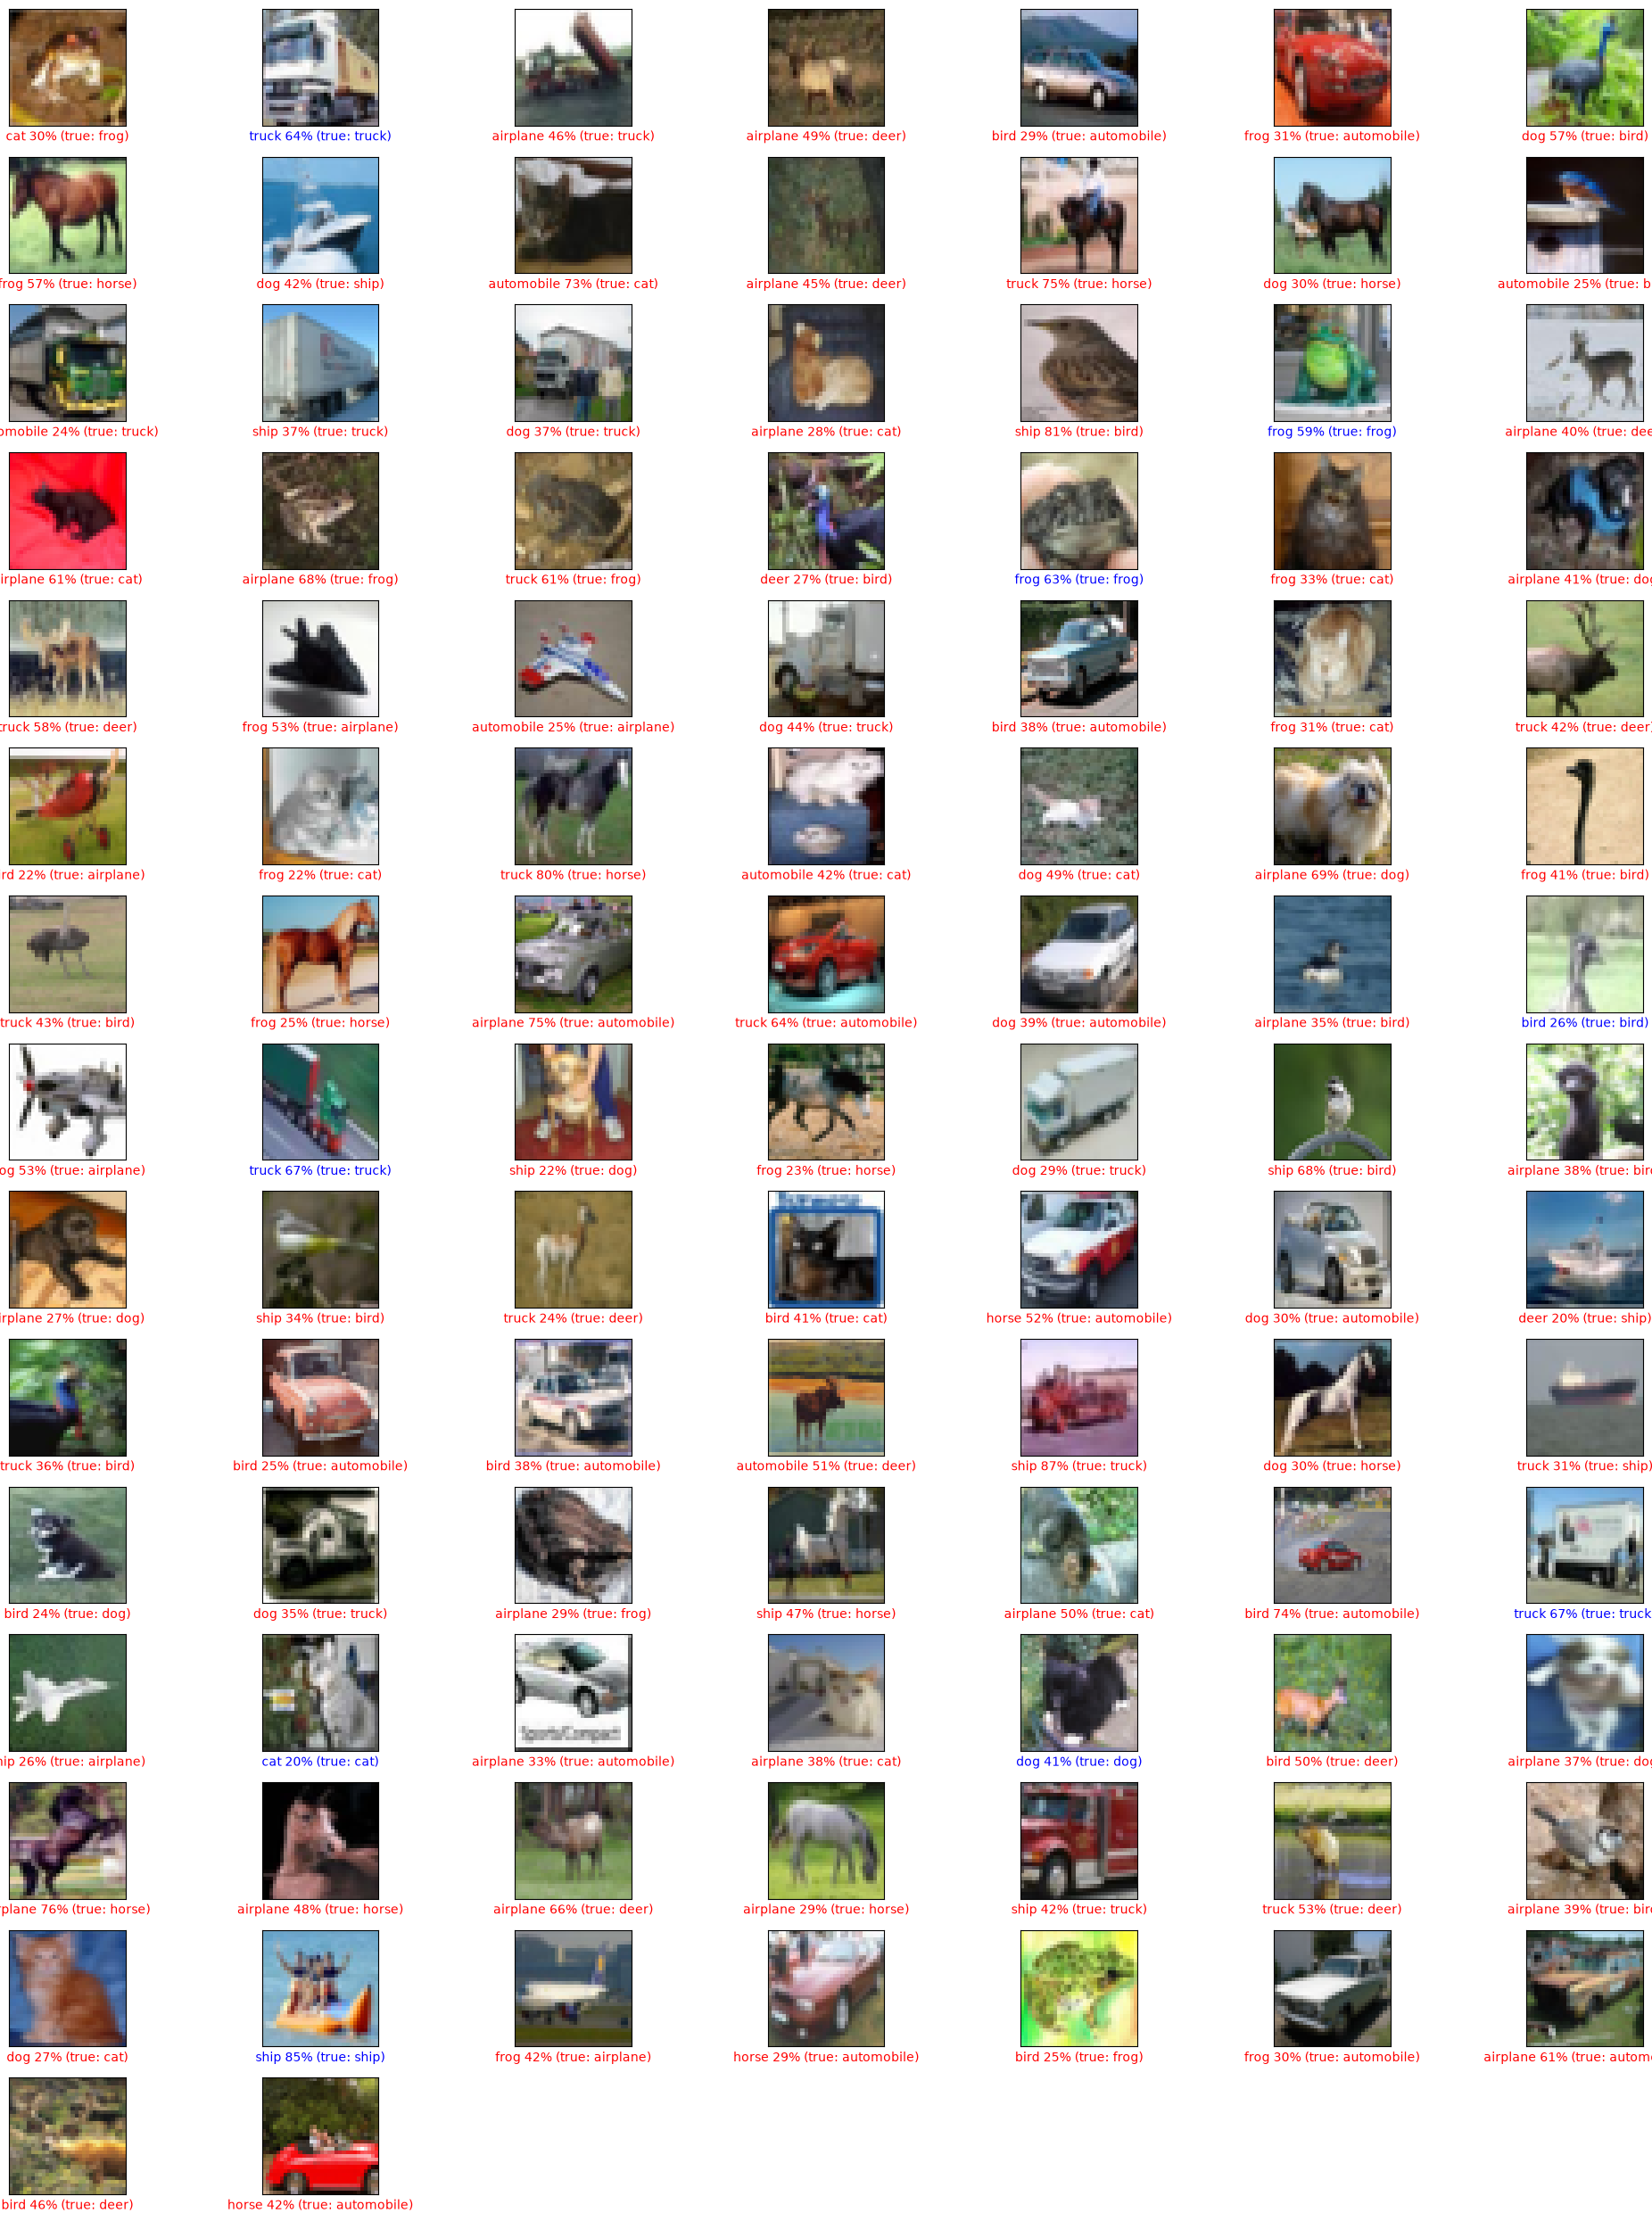

In [38]:
plt.figure(figsize=(20, 25)) 

for i in range(100):
    plt.subplot(15, 7, i+1)
    plot_image(i, predictions, y_train, x_train)

plt.tight_layout()
plt.show()

In [57]:
model = keras.Sequential([
    keras.layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(64, (3,3), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Flatten(),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')
])
learning_rate = 0.01
optimizer = keras.optimizers.Adam(learning_rate = learning_rate)
model.compile(optimizer=optimizer, loss='sparse_categorical_crossentropy', metrics=['accuracy'])

In [58]:
model.fit(x_train, y_train, epochs=15)

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 8ms/step - accuracy: 0.2552 - loss: 1.9646
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.3507 - loss: 1.7483
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.3756 - loss: 1.6858
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.3959 - loss: 1.6532
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.4006 - loss: 1.6416
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.4042 - loss: 1.6387
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.4101 - loss: 1.6257
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.4124 - loss: 1.6236
Epoch 9/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.4146 - loss: 1.6176
Epoch 10/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.4181 - loss: 1.6145
Epoch 11/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.4154 - loss: 1.6125
Epoch 12/15
1563/15

In [62]:
history = model.fit(
    x_train, y_train,
    epochs=15,
    validation_data=(x_test, y_test)
)

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.4157 - loss: 1.6164 - val_accuracy: 0.4007 - val_loss: 1.6778
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.4200 - loss: 1.6101 - val_accuracy: 0.4120 - val_loss: 1.6006
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.4168 - loss: 1.6107 - val_accuracy: 0.4072 - val_loss: 1.6484
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.4185 - loss: 1.6056 - val_accuracy: 0.4139 - val_loss: 1.6203
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.4212 - loss: 1.6035 - val_accuracy: 0.3657 - val_loss: 1.7778
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 9ms/step - accuracy: 0.4208 - loss: 1.6099 - val_accuracy: 0.4306 - val_loss: 1.5734
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 9ms/step - accuracy: 0.4228 - loss: 1.5976 - val_accuracy: 0.3880 - val_loss: 1.7265
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.4223 - los

In [21]:
model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_3 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 502,688 (1.92 MB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 335,126 (1.28 MB)

In [60]:
predictions = model.predict(x_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step


In [55]:
# plt.figure(figsize=(20, 80)) 
# for i in range(10):
#     plt.subplot(10, 1, i+1)
#     plot_image(i, predictions, y_test, x_test)
# plt.tight_layout()
# plt.show()

In [44]:
def plot_value_array(i, predictions_array, true_label):
    predictions_array, true_label = predictions_array[i], true_label[i]
    plt.grid(False)
    # plt.xticks([])
    # plt.yticks([])
    thisplot = plt.bar(range(10), predictions_array, color="#777777") # plot bar
    plt.ylim([0, 1])
    predicted_label = np.argmax(predictions_array)
    # print(predicted_label)

    thisplot[predicted_label].set_color("red")
    thisplot[true_label[0]].set_color("blue")

In [59]:
print(x_train.min(), x_train.max())

0.0 1.0


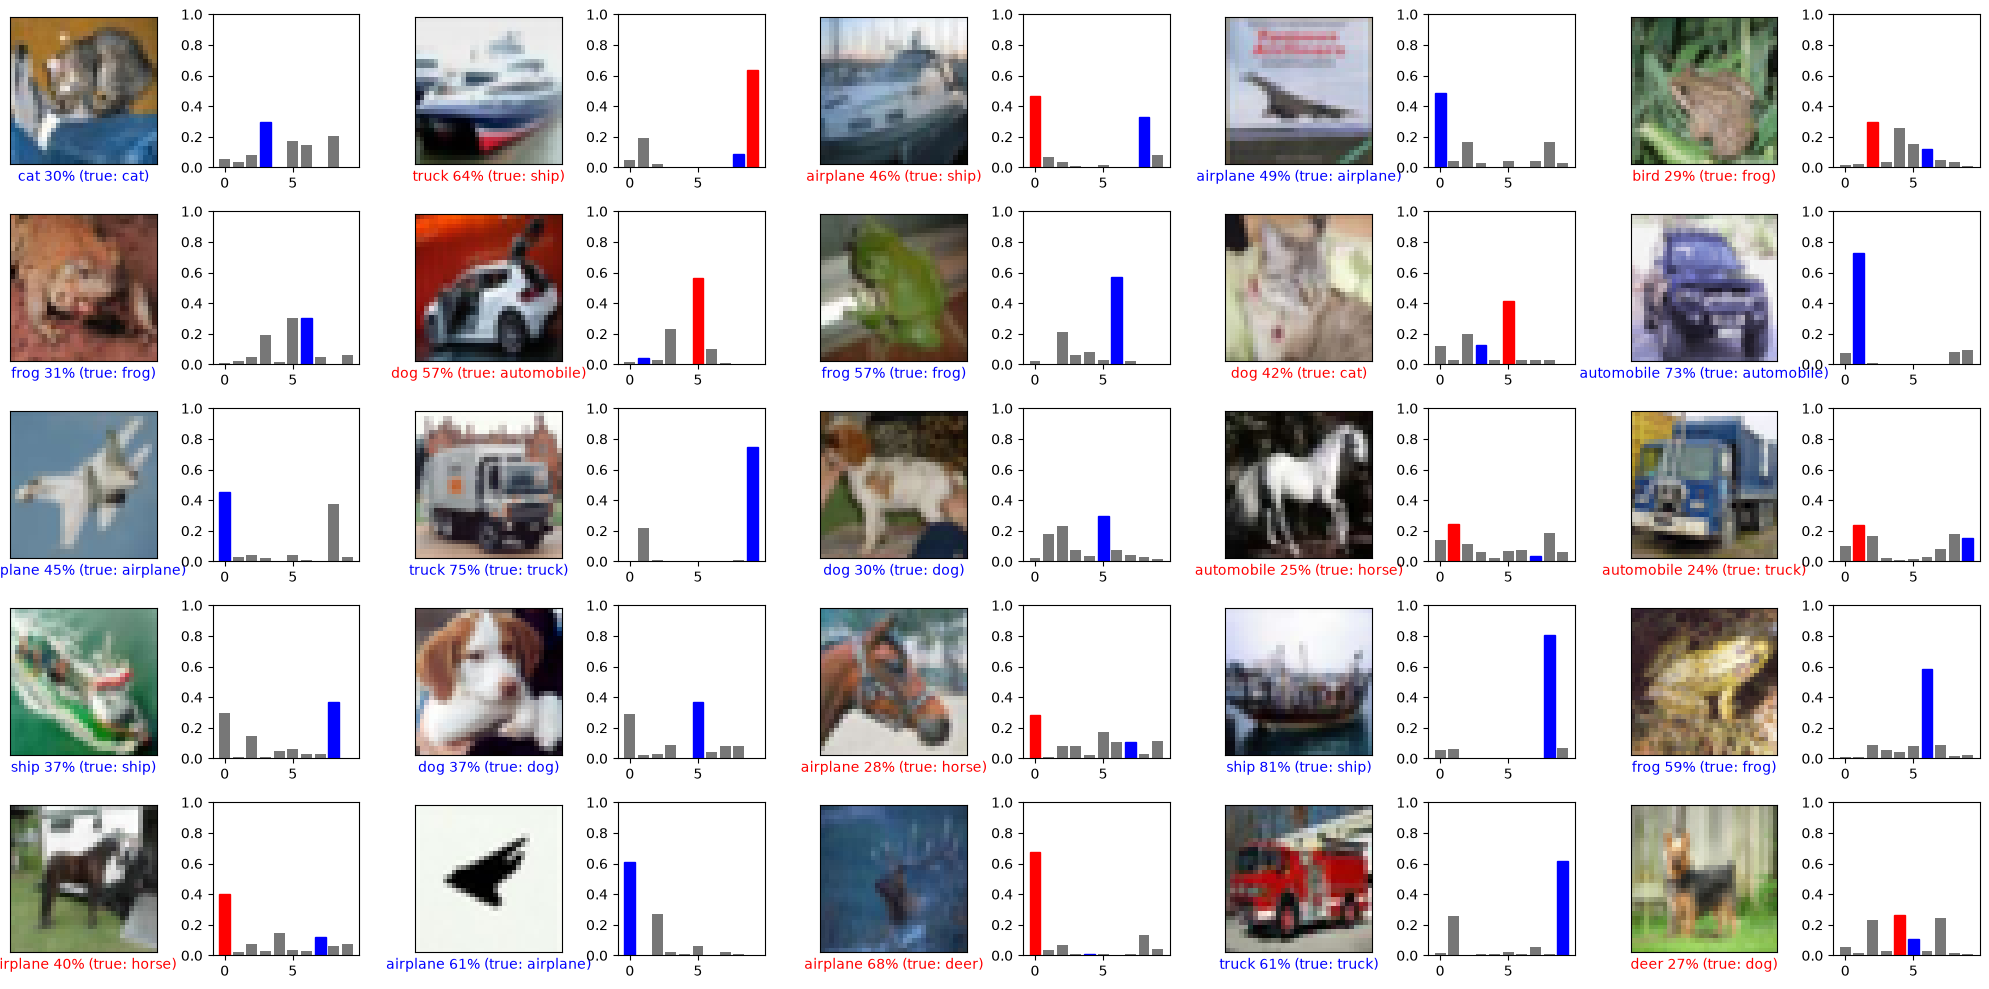

In [56]:
num_rows = 5
num_cols = 5
num_images = num_rows * num_cols
plt.figure(figsize=(2 * 2 * num_cols, 2 * num_rows))
for i in range(num_images):
    plt.subplot(num_rows, 2 * num_cols, 2 * i + 1)
    plot_image(i, predictions, y_test, x_test)
    plt.subplot(num_rows, 2 * num_cols, 2 * i + 2)
    plot_value_array(i, predictions, y_test)
    # _ = plt.xticks(range(10), class_names, rotation=45)

plt.tight_layout()

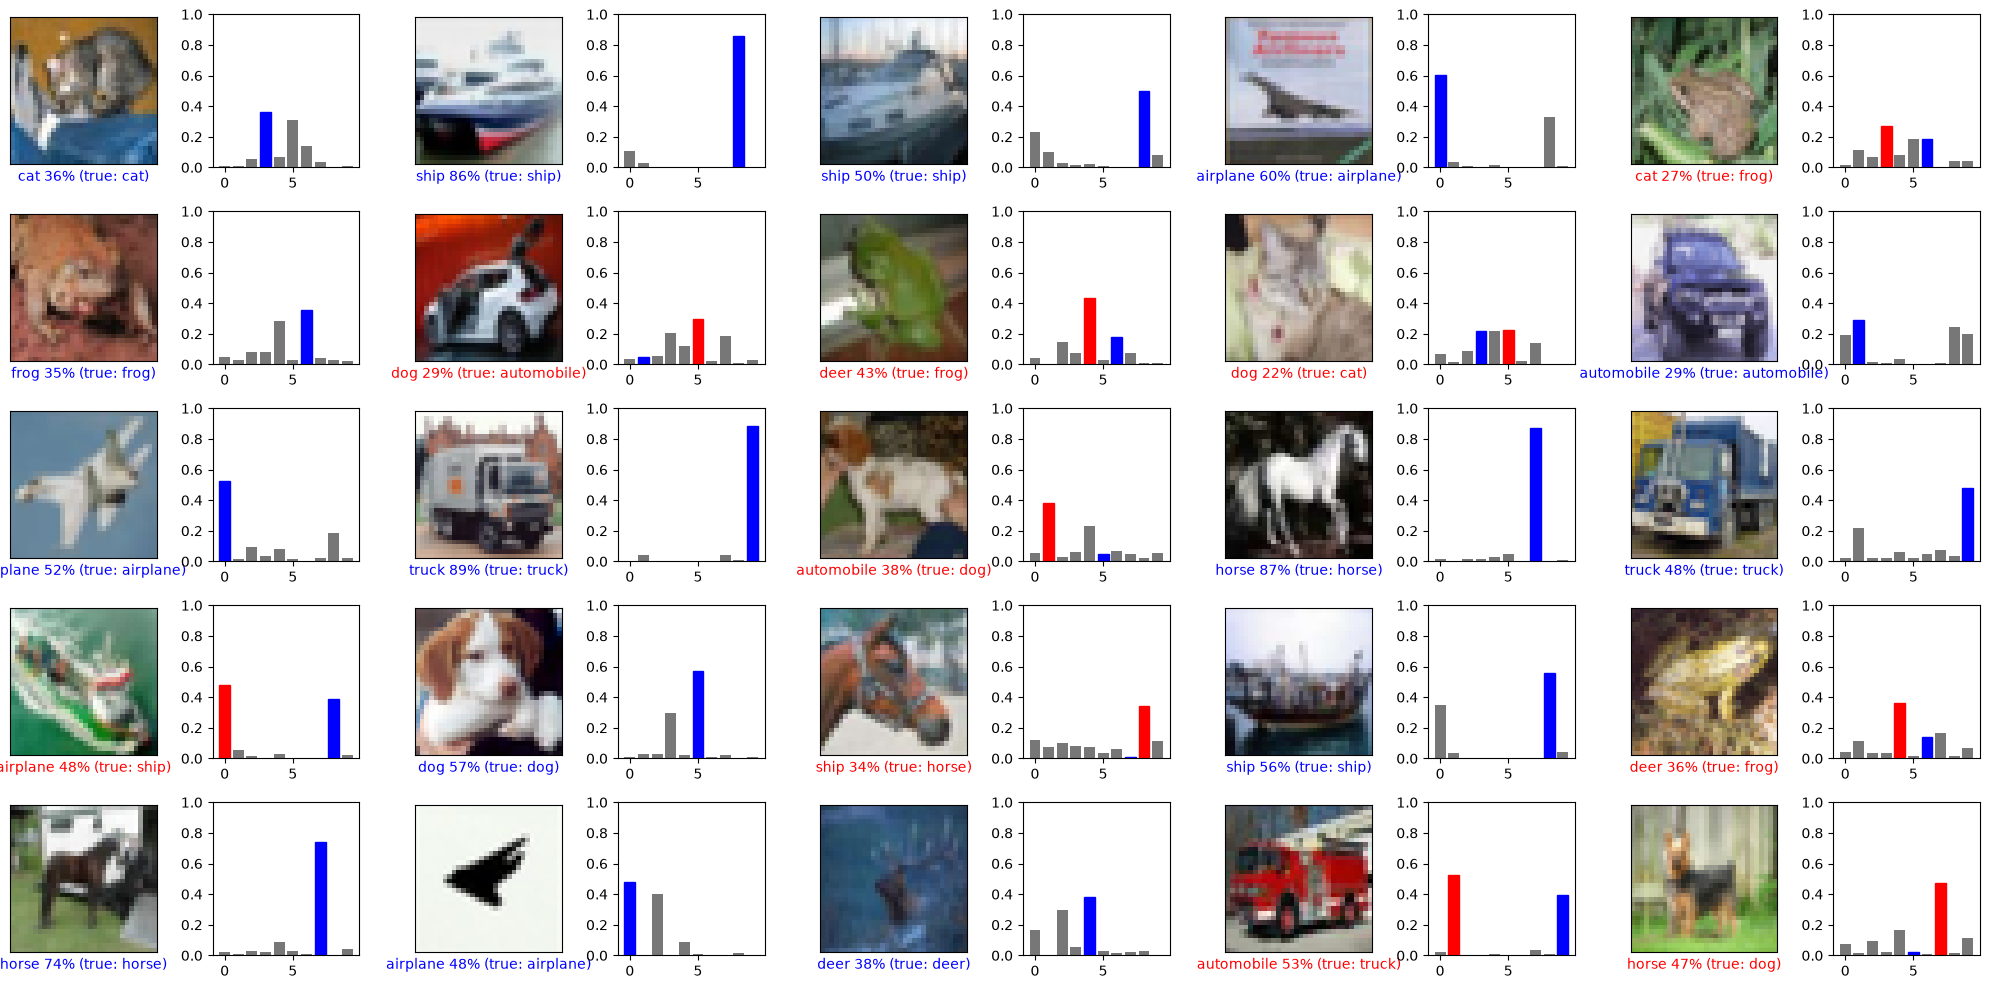

In [61]:
num_rows = 5
num_cols = 5
num_images = num_rows * num_cols
plt.figure(figsize=(2 * 2 * num_cols, 2 * num_rows))
for i in range(num_images):
    plt.subplot(num_rows, 2 * num_cols, 2 * i + 1)
    plot_image(i, predictions, y_test, x_test)
    plt.subplot(num_rows, 2 * num_cols, 2 * i + 2)
    plot_value_array(i, predictions, y_test)
    # _ = plt.xticks(range(10), class_names, rotation=45)

plt.tight_layout()